In [118]:
import torch 
import matplotlib.pyplot as plt 

In [235]:
torch.manual_seed(5) # 초기가중치를 똑같이.. 
X=torch.linspace(0,1,100).reshape(100,1)
y=torch.randn(100).reshape(100,1)

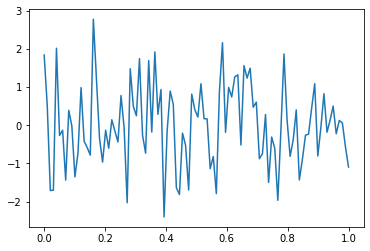

In [236]:
plt.plot(X,y)

### 네트워크 설정, 옵티마이저, 로스 

In [237]:
torch.manual_seed(1) # 초기가중치를 똑같이..
net= torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1))     
optimizer= torch.optim.Adam(net.parameters())
loss_fn=torch.nn.MSELoss() 

### 모형학습

In [258]:
for epoc in range(1000): 
    ## 1 
    yhat= net(X) 
    ## 2 
    loss=loss_fn(yhat,y) 
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()

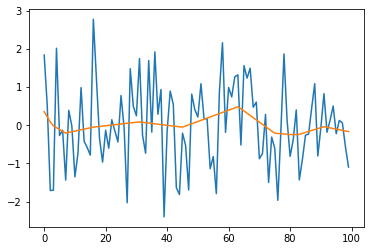

In [259]:
plt.plot(y)
plt.plot(yhat.data)

### Train / Validation  

In [260]:
X1=X[:80]
y1=y[:80]
X2=X[80:]
y2=y[80:]

In [263]:
torch.manual_seed(1) # 초기가중치를 똑같이..
net= torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1))     
optimizer= torch.optim.Adam(net.parameters())
loss_fn=torch.nn.MSELoss() 

In [264]:
tr_loss=[]
val_loss=[]
for epoc in range(1000): 
    ## 1 
    y1hat= net(X1) 
    ## 2 
    loss=loss_fn(y1hat,y1) 
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()
    ## 5 
    tr_loss.append(loss.item())
    val_loss.append(loss_fn(net(X2),y2).item())

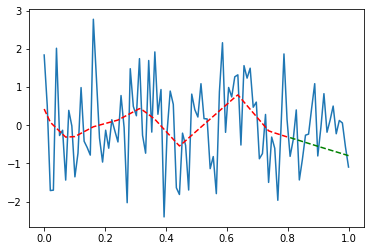

In [265]:
plt.plot(X,y)
plt.plot(X1,y1hat.data,'--r')
plt.plot(X2,net(X2).data,'--g')

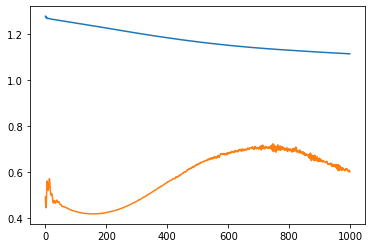

In [266]:
plt.plot(tr_loss)
plt.plot(val_loss)

### 드랍아웃 

In [267]:
X1=X[:80]
y1=y[:80]
X2=X[80:]
y2=y[80:]

In [280]:
torch.manual_seed(1) # 초기가중치를 똑같이..
net= torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.8),
    torch.nn.Linear(512,1))     
optimizer= torch.optim.Adam(net.parameters())
loss_fn=torch.nn.MSELoss() 

In [281]:
tr_loss=[]
val_loss=[]
for epoc in range(1000): 
    ## 1 
    y1hat= net(X1) 
    ## 2 
    loss=loss_fn(y1hat,y1) 
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()
    ## 5 
    tr_loss.append(loss.item())
    val_loss.append(loss_fn(net(X2),y2).item())

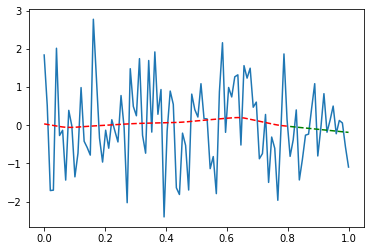

In [282]:
plt.plot(X,y)
net.eval()
plt.plot(X1,net(X1).data,'--r')
net.eval()
plt.plot(X2,net(X2).data,'--g')

### 조기종료 

In [286]:
X1=X[:80]
y1=y[:80]
X2=X[80:]
y2=y[80:]

In [287]:
torch.manual_seed(1) # 초기가중치를 똑같이..
net= torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1))     
optimizer= torch.optim.Adam(net.parameters())
loss_fn=torch.nn.MSELoss() 

In [288]:
tr_loss=[]
val_loss=[]
for epoc in range(200): 
    ## 1 
    y1hat= net(X1) 
    ## 2 
    loss=loss_fn(y1hat,y1) 
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()
    ## 5 
    tr_loss.append(loss.item())
    val_loss.append(loss_fn(net(X2),y2).item())

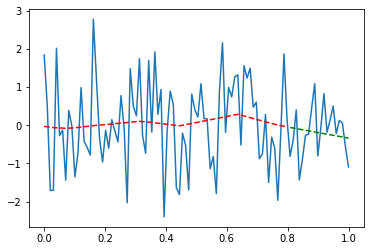

In [289]:
plt.plot(X,y)
plt.plot(X1,y1hat.data,'--r')
plt.plot(X2,net(X2).data,'--g')

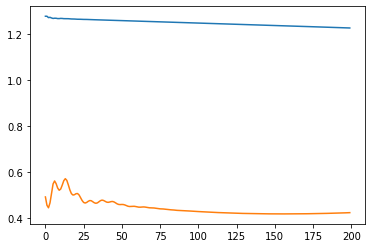

In [290]:
plt.plot(tr_loss)
plt.plot(val_loss)

차라리 이게 낫겠다.. 